# Machine Learning 741 — Assignment 2
## k-Nearest Neighbours and Classification Trees

## 1. Imports and experiment configuration

The configuration below defines the final third-run design. The final evaluation set is selected independently of the tuning set and its row indices are exported so that later sensitivity checks can reuse exactly the same evaluation population.


In [3]:
from pathlib import Path
from time import perf_counter
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 741
TUNING_FOLDS = 3
FINAL_FOLDS = 5
TUNING_SAMPLE_N = 50_000
FINAL_EVAL_SAMPLE_N = 100_000

MODEL_N_JOBS = -1
KNN_SEARCH_N_JOBS = 1
TREE_SEARCH_N_JOBS = -1

KNN_NEIGHBOR_VALUES = [1, 2, 3, 4, 5, 7, 9, 11, 15, 21, 31]
KNN_WEIGHT_VALUES = ["uniform", "distance"]
KNN_P_VALUES = [1, 2]

TREE_CRITERION_VALUES = ["gini", "entropy"]
TREE_DEPTH_VALUES = [None, 5, 10, 15, 20, 25, 30, 40, 50]
TREE_MIN_LEAF_VALUES = [1, 2, 5, 10, 20, 50]
TREE_CLASS_WEIGHT_VALUES = [None, "balanced"]

OVERSAMPLE_FLOOR_RATIOS = [0.02, 0.05, 0.10]
UNDERSAMPLE_CAP_RATIOS = [0.75, 0.50]

CORRELATION_DROP_THRESHOLD = 0.99
DOCUMENTED_REDUNDANT_PAIRS = [
    ("sbytes", "sloss"),
    ("dbytes", "dloss"),
    ("is_ftp_login", "ct_ftp_cmd"),
]

OUTPUT_DIR = Path("ass2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output folder: {OUTPUT_DIR}")
print(f"Tuning sample: {TUNING_SAMPLE_N:,} | Final evaluation sample: {FINAL_EVAL_SAMPLE_N:,}")
print(
    f"Grid sizes — kNN: "
    f"{len(KNN_NEIGHBOR_VALUES) * len(KNN_WEIGHT_VALUES) * len(KNN_P_VALUES)}, "
    f"tree: "
    f"{len(TREE_CRITERION_VALUES) * len(TREE_DEPTH_VALUES) * len(TREE_MIN_LEAF_VALUES) * len(TREE_CLASS_WEIGHT_VALUES)}"
)


Output folder: ass2_outputs
Tuning sample: 50,000 | Final evaluation sample: 100,000
Grid sizes — kNN: 44, tree: 216


## 2. Load the supplied files

The notebook first looks in its current working directory. If the files are not found there, it also checks `/mnt/data`, which is useful when running inside ChatGPT's environment.


In [4]:
REQUIRED_FILES = {
    "traffic": "networkTraffic.csv",
    "features": "features.csv",
    "class_map": "attack_category_map.csv",
}


def resolve_data_dir():
    candidates = [Path.cwd(), Path("/mnt/data")]
    for candidate in candidates:
        if all((candidate / name).exists() for name in REQUIRED_FILES.values()):
            return candidate

    expected = ", ".join(REQUIRED_FILES.values())
    raise FileNotFoundError(
        f"Could not find all required files. Put {expected} in the same directory as this notebook."
    )


DATA_DIR = resolve_data_dir()

traffic = pd.read_csv(DATA_DIR / REQUIRED_FILES["traffic"])
feature_info = pd.read_csv(DATA_DIR / REQUIRED_FILES["features"])
feature_info.columns = feature_info.columns.str.strip()
class_map = pd.read_csv(DATA_DIR / REQUIRED_FILES["class_map"])

print(f"Loaded networkTraffic.csv: {traffic.shape[0]:,} rows × {traffic.shape[1]} columns")
display(traffic.head())


Loaded networkTraffic.csv: 257,673 rows × 44 columns


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,1,0.000011,udp,?,INT,2,0,496,0,90909.0902,...,1,1,2,0,0,0,1,2,0,0
1,2,0.000008,udp,?,INT,2,0,1762,0,125000.0003,...,1,1,2,0,0,0,1,2,0,0
2,3,0.000005,udp,?,INT,2,0,1068,0,200000.0051,...,1,1,3,0,0,0,1,3,0,0
3,4,0.000006,udp,?,INT,2,0,900,0,166666.6608,...,2,1,3,0,0,0,2,3,0,0
4,5,0.000010,udp,?,INT,2,0,2126,0,100000.0025,...,2,1,3,0,0,0,2,3,0,0


## 3. Structural validation

The assignment states that there are 43 descriptive features and the target is the final feature. The assertions are my "sanity" check.

In [5]:
TARGET = "attack_cat"
EXPECTED_DESCRIPTIVE_FEATURES = 43
CATEGORICAL_FEATURES = ["proto", "state", "service"]

assert TARGET in traffic.columns, f"Expected target column '{TARGET}' was not found."
assert traffic.columns[-1] == TARGET, "The target is expected to be the last column."
assert traffic.shape[1] - 1 == EXPECTED_DESCRIPTIVE_FEATURES, (
    f"Expected {EXPECTED_DESCRIPTIVE_FEATURES} descriptive features, "
    f"found {traffic.shape[1] - 1}."
)
assert all(c in traffic.columns for c in CATEGORICAL_FEATURES)

print("Dataset structure matches the assignment specification.")
print(f"Rows: {len(traffic):,}")
print(f"Descriptive features: {traffic.shape[1] - 1}")
print(f"Target: {TARGET}")

Dataset structure matches the assignment specification.
Rows: 257,673
Descriptive features: 43
Target: attack_cat


In [6]:
print(f"id unique values: {traffic['id'].nunique():,} / {len(traffic):,} rows")
assert traffic['id'].nunique(dropna=False) == len(traffic), "id is expected to be unique for every row."

id unique values: 257,673 / 257,673 rows


# Part A — Dataset and remaining data-quality checks

## 4. Dataset and target class distribution

In [7]:
mapping = dict(zip(class_map["Mapping"], class_map["Attack Category Name"]))
class_order = class_map.sort_values("Mapping")["Mapping"].tolist()
class_names = [mapping[c] for c in class_order]

class_counts = (
    traffic[TARGET]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)
class_counts["class_name"] = class_counts.index.map(mapping)
class_counts["percentage"] = 100 * class_counts["count"] / len(traffic)
class_counts = class_counts[["class_name", "count", "percentage"]]

display(class_counts)

,class_name,count,percentage
attack_cat,,,
0,Normal,93000,36.092256
1,Reconnaissance,13987,5.428198
2,Backdoor,2329,0.903859
3,DoS,16353,6.346416
4,Exploits,44525,17.279653
5,Analysis,2677,1.038914
6,Fuzzers,24246,9.409601
7,Worms,174,0.067527
8,Shellcode,1511,0.586402


## 5. Missing-value checks

In [8]:
nan_counts = traffic.isna().sum()
question_counts = pd.Series({
    col: (traffic[col].astype(str).str.strip() == "?").sum()
    for col in traffic.columns
})

missing_stats = pd.DataFrame({
    "nan_count": nan_counts,
    "question_mark_count": question_counts,
})
missing_stats["total_missing_like"] = (
    missing_stats["nan_count"] + missing_stats["question_mark_count"]
)
missing_stats["percentage"] = 100 * missing_stats["total_missing_like"] / len(traffic)
missing_stats = missing_stats[missing_stats["total_missing_like"] > 0].sort_values(
    "percentage", ascending=False
)

display(missing_stats)

,nan_count,question_mark_count,total_missing_like,percentage
service,0,141321,141321,54.845094


### Missing `service` by attack category

In [9]:
service_missing = traffic["service"].astype(str).str.strip().eq("?")

service_missing_count = int(service_missing.sum())
service_missing_pct = 100 * service_missing_count / len(traffic)

print(
    f"Missing service values: {service_missing_count:,} "
    f"({service_missing_pct:.2f}%)"
)


Missing service values: 141,321 (54.85%)


## 6. Nominal predictors

In [10]:
cardinality = pd.DataFrame({
    "feature": CATEGORICAL_FEATURES,
    "unique_values": [
        traffic[c].nunique(dropna=False)
        for c in CATEGORICAL_FEATURES
    ],
})

display(cardinality)


,feature,unique_values
0,proto,133
1,state,11
2,service,13


## 7. Numerical ranges and outliers

In [11]:
numeric_cols_audit = [
    c for c in traffic.select_dtypes(include=np.number).columns
    if c not in [TARGET, "id"]
]

range_rows = []
for col in numeric_cols_audit:
    s = traffic[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((s < lower) | (s > upper)).sum()
    range_rows.append({
        "feature": col,
        "min": s.min(),
        "q1": q1,
        "median": s.median(),
        "q3": q3,
        "max": s.max(),
        "range": s.max() - s.min(),
        "iqr_outlier_count": int(outlier_count),
        "iqr_outlier_percentage": 100 * outlier_count / len(s),
    })

numeric_range_audit = pd.DataFrame(range_rows).set_index("feature")

display(
    numeric_range_audit.sort_values("range", ascending=False).head(15)
)


,min,q1,median,q3,max,range,iqr_outlier_count,iqr_outlier_percentage
feature,,,,,,,,
sload,0.0,12318.004880,743942.312500,8.000000e+07,5.988000e+09,5.988000e+09,22034,8.551148
stcpb,0.0,0.000000,0.000000,2.007375e+09,4.294959e+09,4.294959e+09,0,0.000000
dtcpb,0.0,0.000000,0.000000,1.992752e+09,4.294882e+09,4.294882e+09,0,0.000000
dload,0.0,0.000000,1747.441284,2.210538e+04,2.242273e+07,2.242273e+07,57556,22.336838
dbytes,0.0,0.000000,178.000000,1.064000e+03,1.465753e+07,1.465753e+07,40024,15.532865
sbytes,24.0,114.000000,528.000000,1.362000e+03,1.435577e+07,1.435575e+07,32164,12.482487
response_body_len,0.0,0.000000,0.000000,0.000000e+00,6.558056e+06,6.558056e+06,16951,6.578493
sjit,0.0,0.000000,0.673637,2.787367e+03,1.483831e+06,1.483831e+06,23533,9.132893
rate,0.0,30.789277,2955.664893,1.250000e+05,1.000000e+06,1.000000e+06,23541,9.135998


## 8. Correlation checks

In [12]:
corr = traffic[numeric_cols_audit].corr(method="pearson")
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

correlation_pairs = (
    upper.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
correlation_pairs["abs_correlation"] = correlation_pairs["correlation"].abs()
correlation_pairs = correlation_pairs.sort_values("abs_correlation", ascending=False)

display(correlation_pairs.head(10))

raw_documented_pair_rows = []
for left, right in DOCUMENTED_REDUNDANT_PAIRS:
    if left in traffic.columns and right in traffic.columns:
        left_num = pd.to_numeric(traffic[left], errors="coerce")
        right_num = pd.to_numeric(traffic[right], errors="coerce")
        r = left_num.corr(right_num)
        raw_documented_pair_rows.append({
            "feature_1": left,
            "feature_2": right,
            "correlation": r,
            "abs_correlation": abs(r) if pd.notna(r) else np.nan,
            "audit_stage": "raw_before_modelling_corrections",
        })

raw_documented_pair_audit = pd.DataFrame(raw_documented_pair_rows)
display(raw_documented_pair_audit)

print(
    "These raw correlations are descriptive only. "
    "The kNN drop decision is recomputed after modelling corrections."
)

,feature_1,feature_2,correlation,abs_correlation
726,is_ftp_login,ct_ftp_cmd,0.998855,0.998855
152,dbytes,dloss,0.996711,0.996711
117,sbytes,sloss,0.995772,0.995772
490,swin,dwin,0.980458,0.980458
83,dpkts,dloss,0.979612,0.979612
684,ct_srv_src,ct_srv_dst,0.979467,0.979467
76,dpkts,dbytes,0.973445,0.973445
46,spkts,sloss,0.971859,0.971859
39,spkts,sbytes,0.964393,0.964393
696,ct_dst_ltm,ct_src_dport_ltm,0.961518,0.961518


,feature_1,feature_2,correlation,abs_correlation,audit_stage
0,sbytes,sloss,0.995772,0.995772,raw_before_modelling_corrections
1,dbytes,dloss,0.996711,0.996711,raw_before_modelling_corrections
2,is_ftp_login,ct_ftp_cmd,0.998855,0.998855,raw_before_modelling_corrections


These raw correlations are descriptive only. The kNN drop decision is recomputed after modelling corrections.


## 9. Binary validity check

In [13]:
ftp_login_counts = (
    traffic["is_ftp_login"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)

display(ftp_login_counts)


,count
is_ftp_login,
0,254428
1,3219
2,10
4,16


# Part B — Model-specific preprocessing

## 11. Common preprocessing and modelling tables

In [14]:
data = traffic.copy()

# Target
y = pd.to_numeric(data[TARGET].replace("?", np.nan), errors="coerce")
assert y.notna().all(), "Unexpected missing or invalid target values."
y = y.astype(int).reset_index(drop=True)

# Categorical features
for col in CATEGORICAL_FEATURES:
    data[col] = (
        data[col]
        .astype("string")
        .str.strip()
        .replace("?", pd.NA)
        .fillna("__MISSING__")
        .astype(str)
    )

# Numerical features
numeric_cols = [
    col for col in data.columns
    if col not in CATEGORICAL_FEATURES + [TARGET, "id"]
]

data[numeric_cols] = data[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Restore the intended binary representation
if "is_ftp_login" in data.columns:
    valid = data["is_ftp_login"].notna()
    data.loc[valid, "is_ftp_login"] = (
        data.loc[valid, "is_ftp_login"] > 0
    ).astype(int)

# Base feature set for the tree
X_tree = data.drop(columns=[TARGET, "id"]).reset_index(drop=True)

# Check documented near-duplicate pairs for kNN
corr_rows = []

for feature_1, feature_2 in DOCUMENTED_REDUNDANT_PAIRS:
    r = X_tree[feature_1].corr(X_tree[feature_2])

    corr_rows.append({
        "feature_1": feature_1,
        "feature_2": feature_2,
        "correlation": r,
        "drop_for_knn": abs(r) >= CORRELATION_DROP_THRESHOLD,
    })

corr_check = pd.DataFrame(corr_rows)
display(corr_check)

knn_drop_cols = corr_check.loc[
    corr_check["drop_for_knn"], "feature_2"
].tolist()

X_knn = X_tree.drop(columns=knn_drop_cols)

# Column groups used by the preprocessing pipelines
tree_cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_tree]
knn_cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_knn]

tree_num_cols = [c for c in X_tree.columns if c not in tree_cat_cols]
knn_num_cols = [c for c in X_knn.columns if c not in knn_cat_cols]

tree_missing = int(X_tree[tree_num_cols].isna().sum().sum())
knn_missing = int(X_knn[knn_num_cols].isna().sum().sum())

print(f"Rows available for modelling: {len(y):,}")
print(f"kNN features removed: {knn_drop_cols}")
print(f"Numeric missing cells — kNN: {knn_missing:,}, tree: {tree_missing:,}")

,feature_1,feature_2,correlation,drop_for_knn
0,sbytes,sloss,0.995772,True
1,dbytes,dloss,0.996711,True
2,is_ftp_login,ct_ftp_cmd,0.976717,False


Rows available for modelling: 257,673
kNN features removed: ['sloss', 'dloss']
Numeric missing cells — kNN: 0, tree: 0


## 12. Tuning and final evaluation samples

A stratified 100,000-row final evaluation set is reserved first. A separate 50,000-row tuning sample is then drawn from the remaining observations.

In [15]:
all_idx = np.arange(len(y))

# Reserve the final evaluation set first
eval_idx, _ = train_test_split(
    all_idx,
    train_size=FINAL_EVAL_SAMPLE_N,
    stratify=y,
    random_state=RANDOM_STATE + 100,
)
eval_idx = np.sort(eval_idx)

# Select the tuning set from the remaining observations
remaining_idx = np.setdiff1d(all_idx, eval_idx)

tune_idx, _ = train_test_split(
    remaining_idx,
    train_size=TUNING_SAMPLE_N,
    stratify=y.iloc[remaining_idx],
    random_state=RANDOM_STATE + 200,
)
tune_idx = np.sort(tune_idx)

assert set(eval_idx).isdisjoint(tune_idx)

X_knn_tune = X_knn.iloc[tune_idx].copy()
X_tree_tune = X_tree.iloc[tune_idx].copy()
y_tune = y.iloc[tune_idx].copy()

X_knn_eval = X_knn.iloc[eval_idx].copy()
X_tree_eval = X_tree.iloc[eval_idx].copy()
y_eval = y.iloc[eval_idx].copy()

split_summary = pd.DataFrame({
    "Set": ["Full dataset", "Tuning", "Final evaluation", "Unused"],
    "Rows": [
        len(y),
        len(y_tune),
        len(y_eval),
        len(y) - len(y_tune) - len(y_eval),
    ],
})

display(split_summary)

# Confirm that stratification preserved the class distribution
class_distribution = pd.DataFrame({
    "Full (%)": y.value_counts(normalize=True).sort_index() * 100,
    "Tuning (%)": y_tune.value_counts(normalize=True).sort_index() * 100,
    "Evaluation (%)": y_eval.value_counts(normalize=True).sort_index() * 100,
})
class_distribution.index = class_distribution.index.map(mapping)

display(class_distribution.round(2))


,Set,Rows
0,Full dataset,257673
1,Tuning,50000
2,Final evaluation,100000
3,Unused,107673


,Full (%),Tuning (%),Evaluation (%)
attack_cat,,,
Normal,36.09,36.09,36.09
Reconnaissance,5.43,5.43,5.43
Backdoor,0.90,0.90,0.90
DoS,6.35,6.35,6.35
Exploits,17.28,17.28,17.28
Analysis,1.04,1.04,1.04
Fuzzers,9.41,9.41,9.41
Worms,0.07,0.07,0.07
Shellcode,0.59,0.59,0.59


## 13. kNN and classification-tree pipelines

In [16]:
def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


# Numerical preprocessing
knn_num = RobustScaler()
if knn_missing:
    knn_num = SkPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])

tree_num = "passthrough"
if tree_missing:
    tree_num = SimpleImputer(strategy="median")


# Model-specific preprocessing
knn_prep = ColumnTransformer([
    ("categorical", make_encoder(), knn_cat_cols),
    ("numeric", knn_num, knn_num_cols),
])

tree_prep = ColumnTransformer([
    ("categorical", make_encoder(), tree_cat_cols),
    ("numeric", tree_num, tree_num_cols),
])


# Pipelines are rebuilt later when testing sampling strategies
def make_knn_pipeline(sampler="passthrough"):
    return ImbPipeline([
        ("preprocess", knn_prep),
        ("sampler", sampler),
        ("model", KNeighborsClassifier(
            algorithm="brute",
            n_jobs=MODEL_N_JOBS,
        )),
    ])


def make_tree_pipeline(sampler="passthrough"):
    return ImbPipeline([
        ("preprocess", tree_prep),
        ("sampler", sampler),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
        )),
    ])


knn_pipeline = make_knn_pipeline()
tree_pipeline = make_tree_pipeline()

### Preprocessing summary

This table mirrors the model-specific preprocessing decisions reported in the Methodology section.

In [17]:
preprocessing_summary = pd.DataFrame([
    ["Unique id", "Dropped", "Dropped"],
    ["Missing service", "Missing category", "Missing category"],
    ["Nominal predictors", "One-hot encoded", "One-hot encoded"],
    ["Numerical scale", "Robust-scaled", "Unscaled"],
    ["Outliers", "Retained", "Retained"],
    ["Near-duplicate predictors", f"Dropped: {', '.join(knn_drop_cols)}", "Retained"],
], columns=["Issue", "kNN", "Classification Tree"])

display(preprocessing_summary)


,Issue,kNN,Classification Tree
0,Unique id,Dropped,Dropped
1,Missing service,Missing category,Missing category
2,Nominal predictors,One-hot encoded,One-hot encoded
3,Numerical scale,Robust-scaled,Unscaled
4,Outliers,Retained,Retained
5,Near-duplicate predictors,"Dropped: sloss, dloss",Retained


## 14. Performance and model-selection rules

# Part C — Empirical procedure

## 15. Stratified tuning folds

In [18]:
SCORING = {
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "weighted_f1": "f1_weighted",
    "accuracy": "accuracy",
}

tuning_cv = StratifiedKFold(
    n_splits=TUNING_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

tuning_splits = list(tuning_cv.split(np.zeros(len(y_tune)), y_tune))

print(
    f"Prepared {len(tuning_splits)} shared stratified tuning folds "
    f"for {len(y_tune):,} observations."
)

Prepared 3 shared stratified tuning folds for 50,000 observations.


## 16. kNN control-parameter optimisation

In [19]:
knn_param_grid = {
    "model__n_neighbors": KNN_NEIGHBOR_VALUES,
    "model__weights": KNN_WEIGHT_VALUES,
    "model__p": KNN_P_VALUES,
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring=SCORING,
    refit="macro_f1",
    cv=tuning_splits,
    n_jobs=KNN_SEARCH_N_JOBS,
    verbose=0,
    return_train_score=False,
)

start = perf_counter()
knn_search.fit(X_knn_tune, y_tune)
knn_tune_seconds = perf_counter() - start

print(f"kNN tuning time: {knn_tune_seconds:,.1f} s")
print(f"Best macro-F1: {knn_search.best_score_:.4f}")
print("Best parameters:")
print(knn_search.best_params_)

knn_grid_results = (
    pd.DataFrame(knn_search.cv_results_)
    .sort_values("rank_test_macro_f1")
)

display(
    knn_grid_results[[
        "rank_test_macro_f1",
        "mean_test_macro_f1",
        "std_test_macro_f1",
        "mean_test_balanced_accuracy",
        "mean_test_weighted_f1",
        "mean_test_accuracy",
        "param_model__n_neighbors",
        "param_model__weights",
        "param_model__p",
    ]].head(10)
)


kNN tuning time: 1,296.4 s
Best macro-F1: 0.4977
Best parameters:
{'model__n_neighbors': 2, 'model__p': 1, 'model__weights': 'distance'}


,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_test_balanced_accuracy,mean_test_weighted_f1,mean_test_accuracy,param_model__n_neighbors,param_model__weights,param_model__p
5,1,0.497662,0.007121,0.498610,0.766801,0.76564,2,distance,1
9,2,0.496435,0.010989,0.487947,0.771677,0.77304,3,distance,1
1,3,0.493578,0.005606,0.492811,0.764510,0.76522,1,distance,1
0,3,0.493578,0.005606,0.492811,0.764510,0.76522,1,uniform,1
21,5,0.493211,0.011978,0.479510,0.777685,0.78182,7,distance,1
17,6,0.492437,0.009112,0.480584,0.776906,0.78008,5,distance,1
13,7,0.491809,0.009981,0.480489,0.774935,0.77710,4,distance,1
25,8,0.487822,0.014559,0.473814,0.777664,0.78260,9,distance,1
29,9,0.487227,0.013657,0.472847,0.777162,0.78220,11,distance,1
33,10,0.482725,0.013118,0.467550,0.775380,0.78116,15,distance,1


## 17. Classification-tree control-parameter optimisation

In [20]:
tree_param_grid = {
    "model__criterion": TREE_CRITERION_VALUES,
    "model__max_depth": TREE_DEPTH_VALUES,
    "model__min_samples_leaf": TREE_MIN_LEAF_VALUES,
    "model__class_weight": TREE_CLASS_WEIGHT_VALUES,
}

tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring=SCORING,
    refit="macro_f1",
    cv=tuning_splits,
    n_jobs=TREE_SEARCH_N_JOBS,
    verbose=0,
    return_train_score=False,
)

start = perf_counter()
tree_search.fit(X_tree_tune, y_tune)
tree_tune_seconds = perf_counter() - start

print(f"Tree tuning time: {tree_tune_seconds:,.1f} s")
print(f"Best macro-F1: {tree_search.best_score_:.4f}")
print("Best parameters:")
print(tree_search.best_params_)

tree_grid_results = (
    pd.DataFrame(tree_search.cv_results_)
    .sort_values("rank_test_macro_f1")
)

display(
    tree_grid_results[[
        "rank_test_macro_f1",
        "mean_test_macro_f1",
        "std_test_macro_f1",
        "mean_test_balanced_accuracy",
        "mean_test_weighted_f1",
        "mean_test_accuracy",
        "param_model__criterion",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "param_model__class_weight",
    ]].head(10)
)


Tree tuning time: 116.9 s
Best macro-F1: 0.5423
Best parameters:
{'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 15, 'model__min_samples_leaf': 2}


,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_test_balanced_accuracy,mean_test_weighted_f1,mean_test_accuracy,param_model__criterion,param_model__max_depth,param_model__min_samples_leaf,param_model__class_weight
181,1,0.542315,0.020917,0.587185,0.769660,0.74434,entropy,15,2,balanced
180,2,0.540305,0.010771,0.577229,0.769439,0.74518,entropy,15,1,balanced
3,3,0.537812,0.030595,0.530761,0.796122,0.79996,gini,None,10,None
45,3,0.537812,0.030595,0.530761,0.796122,0.79996,gini,40,10,None
51,3,0.537812,0.030595,0.530761,0.796122,0.79996,gini,50,10,None
33,6,0.537693,0.030134,0.530233,0.796315,0.80048,gini,25,10,None
39,7,0.537502,0.030561,0.530530,0.796086,0.79994,gini,30,10,None
187,8,0.534670,0.024535,0.566596,0.773468,0.75326,entropy,20,2,balanced
27,9,0.533656,0.030678,0.524104,0.794091,0.80190,gini,20,10,None
50,10,0.532157,0.019456,0.519466,0.791300,0.79336,gini,50,5,None


## 18. Class-imbalance strategies

In [21]:
class OversampleFloorStrategy:
    def __init__(self, ratio):
        self.ratio = ratio

    def __call__(self, y_fold):
        counts = pd.Series(y_fold).value_counts()
        floor = int(np.ceil(counts.max() * self.ratio))
        return {c: floor for c, n in counts.items() if n < floor}


class UndersampleCapStrategy:
    def __init__(self, ratio):
        self.ratio = ratio

    def __call__(self, y_fold):
        counts = pd.Series(y_fold).value_counts()
        cap = int(np.floor(counts.max() * self.ratio))
        return {c: cap for c, n in counts.items() if n > cap}


SAMPLER_SPECS = [{"name": "none", "kind": "none", "ratio": None}]
SAMPLER_SPECS += [
    {"name": f"over_{int(r * 100)}pct", "kind": "over", "ratio": r}
    for r in OVERSAMPLE_FLOOR_RATIOS
]
SAMPLER_SPECS += [
    {"name": f"under_{int(r * 100)}pct", "kind": "under", "ratio": r}
    for r in UNDERSAMPLE_CAP_RATIOS
]


def make_sampler(spec):
    if spec["kind"] == "none":
        return "passthrough"
    if spec["kind"] == "over":
        return RandomOverSampler(
            sampling_strategy=OversampleFloorStrategy(spec["ratio"]),
            random_state=RANDOM_STATE,
        )
    return RandomUnderSampler(
        sampling_strategy=UndersampleCapStrategy(spec["ratio"]),
        random_state=RANDOM_STATE,
    )



## 19. Sampling comparison

In [22]:
def evaluate_sampling(
    model_name,
    make_pipeline,
    params,
    X,
    y,
    specs,
    splits,
    n_jobs,
):
    rows = []

    for spec in specs:
        model = make_pipeline(make_sampler(spec))
        model.set_params(**params)

        scores = cross_validate(
            model,
            X,
            y,
            cv=splits,
            scoring=SCORING,
            n_jobs=n_jobs,
            error_score="raise",
        )

        rows.append({
            "model": model_name,
            "sampler": spec["name"],
            "mean_macro_f1": scores["test_macro_f1"].mean(),
            "std_macro_f1": scores["test_macro_f1"].std(ddof=1),
            "mean_balanced_accuracy": scores["test_balanced_accuracy"].mean(),
            "mean_weighted_f1": scores["test_weighted_f1"].mean(),
            "mean_accuracy": scores["test_accuracy"].mean(),
        })

    return pd.DataFrame(rows).sort_values(
        ["mean_macro_f1", "mean_balanced_accuracy"],
        ascending=False,
    )


knn_sampling = evaluate_sampling(
    "kNN",
    make_knn_pipeline,
    knn_search.best_params_,
    X_knn_tune,
    y_tune,
    SAMPLER_SPECS,
    tuning_splits,
    KNN_SEARCH_N_JOBS,
)

tree_sampling = evaluate_sampling(
    "Classification Tree",
    make_tree_pipeline,
    tree_search.best_params_,
    X_tree_tune,
    y_tune,
    SAMPLER_SPECS,
    tuning_splits,
    TREE_SEARCH_N_JOBS,
)

sampling_results = pd.concat(
    [knn_sampling, tree_sampling],
    ignore_index=True,
)

sampler_order = [
    "none",
    "over_2pct",
    "over_5pct",
    "over_10pct",
    "under_75pct",
    "under_50pct",
]

sampling_display = sampling_results.copy()
sampling_display["sampler"] = pd.Categorical(
    sampling_display["sampler"],
    categories=sampler_order,
    ordered=True,
)
sampling_display = sampling_display.sort_values(["model", "sampler"])

display(
    sampling_display[
        ["model", "sampler", "mean_macro_f1"]
    ].rename(columns={
        "model": "Model",
        "sampler": "Sampling",
        "mean_macro_f1": "Macro-F1",
    }).round(4)
)


,Model,Sampling,Macro-F1
7,Classification Tree,none,0.5423
8,Classification Tree,over_2pct,0.5407
6,Classification Tree,over_5pct,0.5426
9,Classification Tree,over_10pct,0.5373
10,Classification Tree,under_75pct,0.5353
11,Classification Tree,under_50pct,0.5348
0,kNN,none,0.4977
1,kNN,over_2pct,0.4977
2,kNN,over_5pct,0.4977
3,kNN,over_10pct,0.4977


## 20. Re-tuning after sampling

In [23]:
def get_sampler(name):
    return next(spec for spec in SAMPLER_SPECS if spec["name"] == name)


def retune_if_sampled(
    model_name,
    make_pipeline,
    sampler_spec,
    param_grid,
    X,
    y,
    splits,
    n_jobs,
    unsampled_search,
):
    if sampler_spec["kind"] == "none":
        return {
            "search": unsampled_search,
            "sampler_spec": sampler_spec,
            "source": "unsampled grid",
        }

    search = GridSearchCV(
        make_pipeline(make_sampler(sampler_spec)),
        param_grid,
        scoring=SCORING,
        refit="macro_f1",
        cv=splits,
        n_jobs=n_jobs,
        verbose=0,
    )
    search.fit(X, y)


    return {
        "search": search,
        "sampler_spec": sampler_spec,
        "source": "sampled grid",
    }


knn_sampler = get_sampler(knn_sampling.iloc[0]["sampler"])
tree_sampler = get_sampler(tree_sampling.iloc[0]["sampler"])

knn_selection = retune_if_sampled(
    "kNN",
    make_knn_pipeline,
    knn_sampler,
    knn_param_grid,
    X_knn_tune,
    y_tune,
    tuning_splits,
    KNN_SEARCH_N_JOBS,
    knn_search,
)

tree_selection = retune_if_sampled(
    "Classification Tree",
    make_tree_pipeline,
    tree_sampler,
    tree_param_grid,
    X_tree_tune,
    y_tune,
    tuning_splits,
    TREE_SEARCH_N_JOBS,
    tree_search,
)


## 21. Selected configurations

In [24]:
knn_params = knn_selection["search"].best_params_.copy()
tree_params = tree_selection["search"].best_params_.copy()

knn_final_pipeline = make_knn_pipeline(make_sampler(knn_sampler))
tree_final_pipeline = make_tree_pipeline(make_sampler(tree_sampler))

selected_config = {
    "random_state": RANDOM_STATE,
    "tuning_rows": len(y_tune),
    "final_evaluation_rows": len(y_eval),
    "primary_metric": "macro_f1",
    "knn_redundant_features_dropped": knn_drop_cols,
    "knn_sampling": knn_sampler,
    "knn_tuning_macro_f1": float(knn_selection["search"].best_score_),
    "knn_params": knn_params,
    "tree_sampling": tree_sampler,
    "tree_tuning_macro_f1": float(tree_selection["search"].best_score_),
    "tree_params": tree_params,
}


### Selected control parameters

The configurations below are carried into the locked final evaluation.

In [25]:
selected_params_table = pd.DataFrame([
    ["kNN", "Tuning macro-F1", f"{knn_selection['search'].best_score_:.4f}"],
    ["kNN", "k", knn_params["model__n_neighbors"]],
    ["kNN", "Distance", "Manhattan" if knn_params["model__p"] == 1 else "Euclidean"],
    ["kNN", "Voting", knn_params["model__weights"]],
    ["kNN", "Sampling", knn_sampler["name"]],
    ["Tree", "Tuning macro-F1", f"{tree_selection['search'].best_score_:.4f}"],
    ["Tree", "Criterion", tree_params["model__criterion"]],
    ["Tree", "Maximum depth", tree_params["model__max_depth"]],
    ["Tree", "Minimum leaf size", tree_params["model__min_samples_leaf"]],
    ["Tree", "Class weighting", tree_params["model__class_weight"]],
    ["Tree", "Sampling", tree_sampler["name"]],
], columns=["Model", "Parameter", "Selected value"])

display(selected_params_table)


,Model,Parameter,Selected value
0,kNN,Tuning macro-F1,0.4977
1,kNN,k,2
2,kNN,Distance,Manhattan
3,kNN,Voting,distance
4,kNN,Sampling,none
5,Tree,Tuning macro-F1,0.5429
6,Tree,Criterion,entropy
7,Tree,Maximum depth,15
8,Tree,Minimum leaf size,1
9,Tree,Class weighting,balanced


# Part D — Locked final five-fold evaluation

## 22. Final-evaluation helper

In [26]:
def evaluate_cv(name, pipeline, params, X, y, splits, class_order):
    fold_rows = []
    oof_pred = np.full(len(y), -1, dtype=int)

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        model = pipeline.set_params(**params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])

        pred = model.predict(X.iloc[test_idx])
        oof_pred[test_idx] = pred
        y_test = y.iloc[test_idx]

        fold_rows.append({
            "model": name,
            "fold": fold,
            "macro_f1": f1_score(
                y_test,
                pred,
                labels=class_order,
                average="macro",
                zero_division=0,
            ),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "weighted_f1": f1_score(
                y_test,
                pred,
                average="weighted",
                zero_division=0,
            ),
            "accuracy": accuracy_score(y_test, pred),
        })

    report = classification_report(
        y,
        oof_pred,
        labels=class_order,
        target_names=[mapping[c] for c in class_order],
        output_dict=True,
        zero_division=0,
    )

    per_class = (
        pd.DataFrame(report)
        .T
        .loc[
            [mapping[c] for c in class_order],
            ["precision", "recall", "f1-score", "support"],
        ]
        .reset_index()
        .rename(columns={"index": "class_name"})
    )
    per_class.insert(0, "model", name)

    return {
        "fold_metrics": pd.DataFrame(fold_rows),
        "per_class": per_class,
        "cm_norm": confusion_matrix(
            y,
            oof_pred,
            labels=class_order,
            normalize="true",
        ),
    }


final_cv = StratifiedKFold(
    n_splits=FINAL_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE + 2,
)

final_splits = list(
    final_cv.split(np.zeros(len(y_eval)), y_eval)
)


## 23. Evaluate selected kNN

In [27]:
knn_final = evaluate_cv(
    "kNN",
    knn_final_pipeline,
    knn_params,
    X_knn_eval,
    y_eval,
    final_splits,
    class_order,
)


## 24. Evaluate selected classification tree

In [28]:
tree_final = evaluate_cv(
    "Classification Tree",
    tree_final_pipeline,
    tree_params,
    X_tree_eval,
    y_eval,
    final_splits,
    class_order,
)


# Part E — Report-facing results

## Hyperparameter sensitivity

These plots show how tuning macro-F1 changes around the selected configurations.

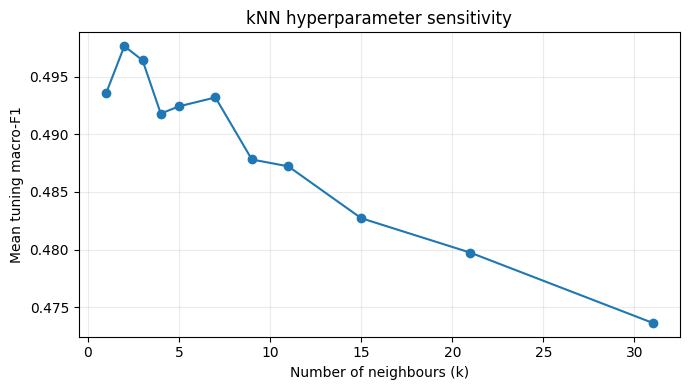

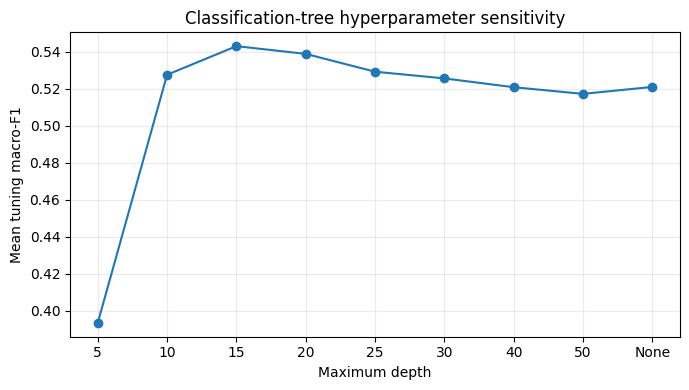

In [29]:
# kNN sensitivity for the selected distance and voting strategy.
knn_sensitivity = pd.DataFrame(knn_search.cv_results_)
knn_sensitivity = knn_sensitivity[
    (knn_sensitivity["param_model__weights"] == knn_params["model__weights"])
    & (knn_sensitivity["param_model__p"] == knn_params["model__p"])
].copy()
knn_sensitivity = knn_sensitivity.sort_values("param_model__n_neighbors")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    knn_sensitivity["param_model__n_neighbors"].astype(int),
    knn_sensitivity["mean_test_macro_f1"],
    marker="o",
)
ax.set_xlabel("Number of neighbours (k)")
ax.set_ylabel("Mean tuning macro-F1")
ax.set_title("kNN hyperparameter sensitivity")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "knn_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

# Tree sensitivity with all other selected controls fixed.
tree_sensitivity = pd.DataFrame(tree_selection["search"].cv_results_)
tree_sensitivity = tree_sensitivity[
    (tree_sensitivity["param_model__criterion"] == tree_params["model__criterion"])
    & (tree_sensitivity["param_model__min_samples_leaf"] == tree_params["model__min_samples_leaf"])
    & (tree_sensitivity["param_model__class_weight"] == tree_params["model__class_weight"])
].copy()

depth_order = TREE_DEPTH_VALUES
tree_sensitivity["_depth_order"] = tree_sensitivity["param_model__max_depth"].map(
    {depth: i for i, depth in enumerate(depth_order)}
)
tree_sensitivity = tree_sensitivity.sort_values("_depth_order")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    range(len(tree_sensitivity)),
    tree_sensitivity["mean_test_macro_f1"],
    marker="o",
)
ax.set_xticks(
    range(len(tree_sensitivity)),
    ["None" if d is None else str(d) for d in tree_sensitivity["param_model__max_depth"]],
)
ax.set_xlabel("Maximum depth")
ax.set_ylabel("Mean tuning macro-F1")
ax.set_title("Classification-tree hyperparameter sensitivity")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tree_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()


## 25. Final overall performance

In [30]:
fold_metrics = pd.concat(
    [knn_final["fold_metrics"], tree_final["fold_metrics"]],
    ignore_index=True,
)

metrics = [
    "macro_f1",
    "balanced_accuracy",
    "weighted_f1",
    "accuracy",
]

model_summary = (
    fold_metrics
    .groupby("model")[metrics]
    .agg(["mean", "std"])
)

final_summary = pd.DataFrame(index=model_summary.index)

for metric, label in [
    ("macro_f1", "Macro-F1"),
    ("balanced_accuracy", "Balanced Accuracy"),
    ("weighted_f1", "Weighted-F1"),
    ("accuracy", "Accuracy"),
]:
    final_summary[label] = [
        f"{mean:.4f} ± {std:.4f}"
        for mean, std in zip(
            model_summary[(metric, "mean")],
            model_summary[(metric, "std")],
        )
    ]

display(final_summary)


,Macro-F1,Balanced Accuracy,Weighted-F1,Accuracy
model,,,,
Classification Tree,0.5508 ± 0.0127,0.6107 ± 0.0219,0.7796 ± 0.0056,0.7537 ± 0.0082
kNN,0.4929 ± 0.0045,0.4973 ± 0.0048,0.7726 ± 0.0020,0.7707 ± 0.0021


## 26. Fold-level stability

In [31]:
fold_macro_f1 = fold_metrics.pivot(
    index="fold",
    columns="model",
    values="macro_f1",
)

display(
    fold_macro_f1.rename_axis("Fold").round(4)
)


model,Classification Tree,kNN
Fold,,
1,0.5318,0.4875
2,0.5559,0.5000
3,0.5576,0.4918
4,0.5447,0.4932
5,0.5639,0.4920


### Fold macro-F1 stability

The same five folds were used for both classifiers. The plot shows the paired macro-F1 values and complements the reported mean and standard deviation.

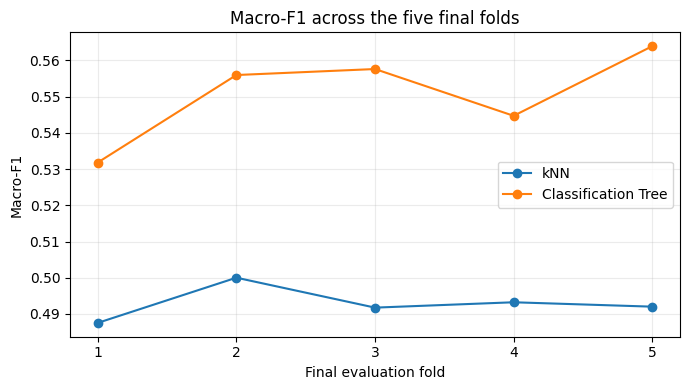

Classification tree higher macro-F1 in 5/5 folds.


In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
for model_name in ["kNN", "Classification Tree"]:
    ax.plot(
        fold_macro_f1.index,
        fold_macro_f1[model_name],
        marker="o",
        label=model_name,
    )

ax.set_xlabel("Final evaluation fold")
ax.set_ylabel("Macro-F1")
ax.set_title("Macro-F1 across the five final folds")
ax.set_xticks(fold_macro_f1.index)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fold_macro_f1_stability.png", dpi=300, bbox_inches="tight")
plt.show()

tree_fold_wins = (
    fold_macro_f1["Classification Tree"] > fold_macro_f1["kNN"]
).sum()
print(f"Classification tree higher macro-F1 in {tree_fold_wins}/{len(fold_macro_f1)} folds.")


## 27. Per-class performance

In [33]:
per_class = pd.concat(
    [knn_final["per_class"], tree_final["per_class"]],
    ignore_index=True,
)

per_class_f1 = (
    per_class
    .pivot(
        index="class_name",
        columns="model",
        values="f1-score",
    )
    .reindex(class_names)
    .rename_axis("Attack Class")
)

display(per_class_f1.round(4))


model,Classification Tree,kNN
Attack Class,,
Normal,0.8576,0.8907
Reconnaissance,0.8159,0.6359
Backdoor,0.0971,0.0724
DoS,0.4323,0.3908
Exploits,0.6354,0.6523
Analysis,0.1458,0.1421
Fuzzers,0.6128,0.5282
Worms,0.4027,0.2462
Shellcode,0.5227,0.3924


## 28. Confusion analysis

Normalized out-of-fold confusion matrices are generated for the two selected classifiers. Rows correspond to the true class, so diagonal entries represent class recall.

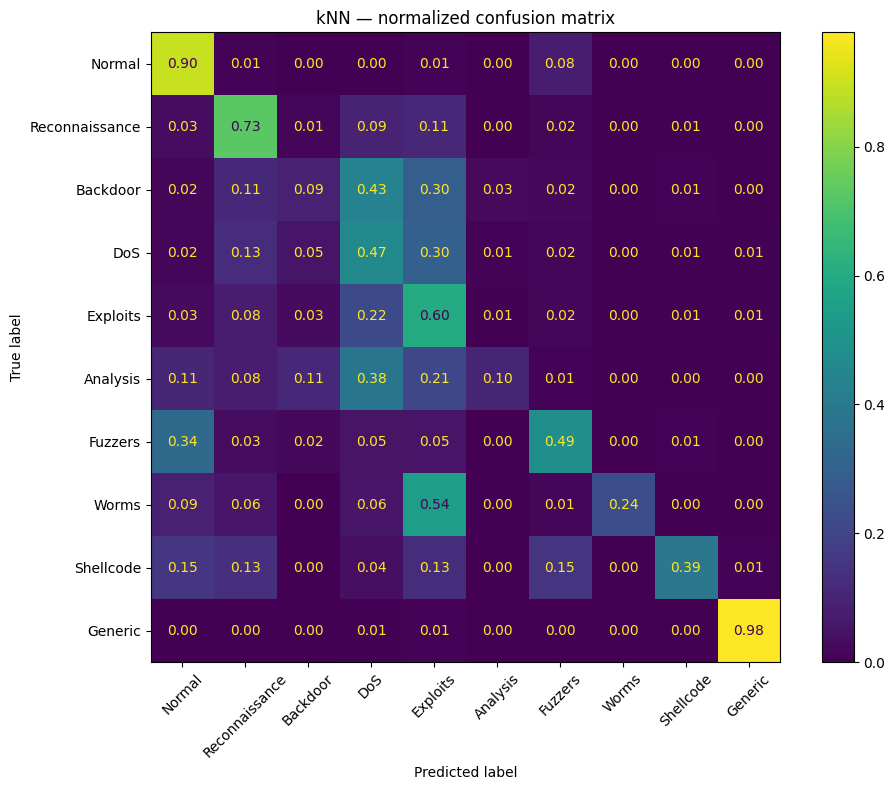

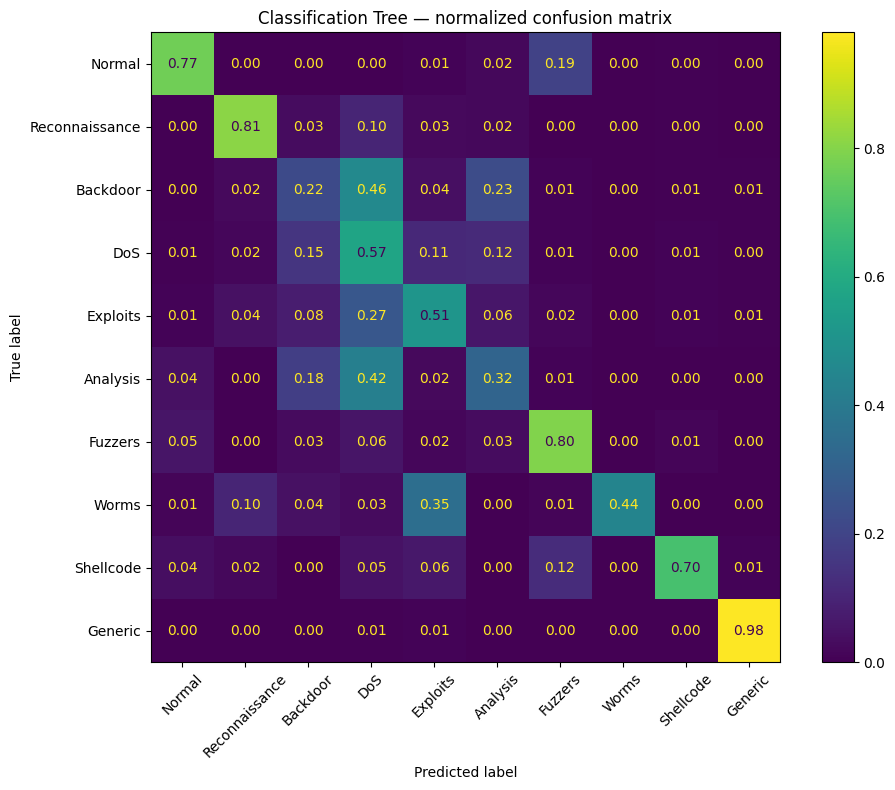

In [34]:
for model_name, result in [
    ("kNN", knn_final),
    ("Classification Tree", tree_final),
]:
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay(
        confusion_matrix=result["cm_norm"],
        display_labels=class_names,
    ).plot(ax=ax, xticks_rotation=45, values_format=".2f")

    ax.set_title(f"{model_name} — normalized confusion matrix")
    plt.tight_layout()

    filename = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


## 29. Final model selection

In [35]:
macro_f1_by_model = (
    fold_metrics
    .groupby("model")["macro_f1"]
    .mean()
    .sort_values(ascending=False)
)

best_model = macro_f1_by_model.index[0]
macro_f1_gap = macro_f1_by_model.iloc[0] - macro_f1_by_model.iloc[1]

print(
    f"Preferred model: {best_model} "
    f"(macro-F1 advantage: {macro_f1_gap:.4f})"
)


Preferred model: Classification Tree (macro-F1 advantage: 0.0579)


## 30. Save report outputs

The numerical results remain visible in the executed notebook. Only the report figures and the final selected configuration are saved to disk.

In [36]:
with open(OUTPUT_DIR / "selected_configuration.json", "w") as f:
    json.dump(selected_config, f, indent=2, default=str)

print(f"Saved figures and selected configuration to: {OUTPUT_DIR.resolve()}")


Saved figures and selected configuration to: /home/james/CS741-Assignments/Assignment2/Machine-Learning-741/ass2_outputs
